# Week 1 — Time Series Data: A Healthcare Example

**Maths for Data Science II**

A **time series dataset** follows **one unit** (here: a single patient) over **many time periods**.

Key features:

- One row per **time period**, one patient only
- Observations are **ordered** — the time index carries information
- Observations are usually **not independent**: today's value depends on yesterday's (**serial correlation**)
- May contain a **trend** and **seasonality**

Below we simulate 24 monthly check-ups for one hypertensive patient who starts
medication after month 6.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
rng = np.random.default_rng(7)

## 2. Build the dataset

**Patient 1** attends a monthly check-up from January 2024 to December 2025.

| Variable | Description |
|---|---|
| `date` | month of the check-up (the **time index**) |
| `sbp` | systolic blood pressure (mmHg) |
| `weight` | body weight (kg) |
| `on_medication` | 0 = before treatment, 1 = after treatment started |

Note how `sbp` is built: each month's value depends on the **previous month's** value.
That is what creates serial correlation.

In [2]:
T = 24
dates = pd.date_range("2024-01-31", periods=T, freq="ME")
on_med = (np.arange(T) >= 6).astype(int)          # treatment starts in month 7

# Serially correlated blood pressure: this month = last month pulled toward a target
sbp = np.empty(T)
sbp[0] = 155.0
for t in range(1, T):
    target = 155 - 15 * on_med[t]                 # medication lowers the target level
    sbp[t] = sbp[t - 1] + 0.4 * (target - sbp[t - 1]) + rng.normal(0, 3)

# Weight: slow downward trend plus noise
weight = 92 - 0.25 * np.arange(T) + rng.normal(0, 0.6, T)

ts = pd.DataFrame({
    "date": dates,
    "sbp": sbp.round(1),
    "weight": weight.round(1),
    "on_medication": on_med,
}).set_index("date")

ts.head(10)

,sbp,weight,on_medication
date,,,
2024-01-31,155.0,92.2,0
2024-02-29,155.0,91.8,0
2024-03-31,155.9,91.4,0
2024-04-30,154.7,89.7,0
2024-05-31,152.2,90.7,0
2024-06-30,151.9,90.7,0
2024-07-31,144.2,90.6,1
2024-08-31,142.7,89.3,1
2024-09-30,145.6,89.7,1


## 3. Inspect the structure

Compare with the cross-sectional notebook: here the **index is time**, and there is only **one patient**.

In [3]:
print("Shape (rows = months, columns = variables):", ts.shape)
print("From", ts.index.min().date(), "to", ts.index.max().date())
ts.info()

Shape (rows = months, columns = variables): (24, 3)
From 2024-01-31 to 2025-12-31
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2024-01-31 to 2025-12-31
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sbp            24 non-null     float64
 1   weight         24 non-null     float64
 2   on_medication  24 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 768.0 bytes


## 4. Descriptive statistics

In [4]:
ts[["sbp", "weight"]].describe().round(2)

,sbp,weight
count,24.00,24.00
mean,142.17,88.96
std,8.21,1.73
min,129.40,85.60
25%,136.78,87.75
50%,141.30,89.00
75%,147.18,90.08
max,155.90,92.20


## 5. Plot the series over time

The **line plot** is the natural chart for time series — connecting the points is meaningful
because consecutive observations are related.

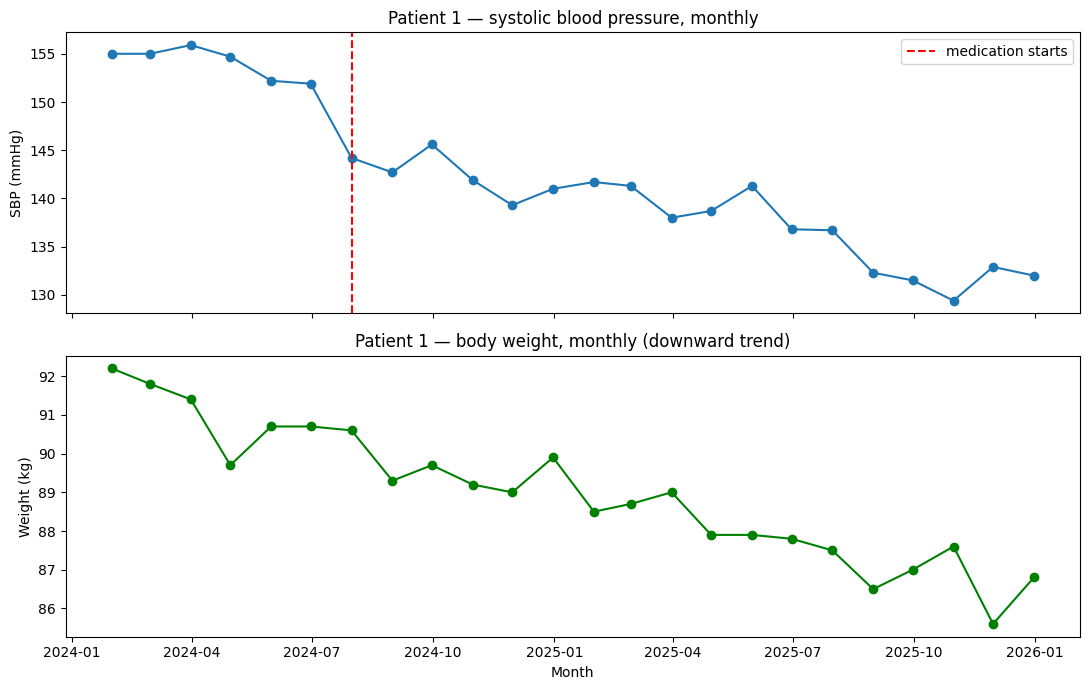

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(ts.index, ts["sbp"], marker="o")
axes[0].axvline(ts.index[6], color="red", linestyle="--", label="medication starts")
axes[0].set_ylabel("SBP (mmHg)")
axes[0].set_title("Patient 1 — systolic blood pressure, monthly")
axes[0].legend()

axes[1].plot(ts.index, ts["weight"], marker="o", color="green")
axes[1].set_ylabel("Weight (kg)")
axes[1].set_title("Patient 1 — body weight, monthly (downward trend)")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

## 6. Time series operations

Two things we can do with time series that make **no sense** for cross-sectional data:
compute **lags** (the previous period's value) and **differences** (the change since last period).

In [6]:
ts["sbp_lag1"] = ts["sbp"].shift(1)          # value one month earlier
ts["sbp_change"] = ts["sbp"].diff()          # change since last month
ts["sbp_ma3"] = ts["sbp"].rolling(3).mean()  # 3-month moving average

ts[["sbp", "sbp_lag1", "sbp_change", "sbp_ma3"]].head(8).round(2)

,sbp,sbp_lag1,sbp_change,sbp_ma3
date,,,,
2024-01-31,155.0,NaN,NaN,NaN
2024-02-29,155.0,155.0,0.0,NaN
2024-03-31,155.9,155.0,0.9,155.30
2024-04-30,154.7,155.9,-1.2,155.20
2024-05-31,152.2,154.7,-2.5,154.27
2024-06-30,151.9,152.2,-0.3,152.93
2024-07-31,144.2,151.9,-7.7,149.43
2024-08-31,142.7,144.2,-1.5,146.27


## 7. Serial correlation

If observations were independent (as we assume for cross-sections), the correlation between
`sbp` and its own lag would be near zero. It is not.

In [7]:
r1 = ts["sbp"].corr(ts["sbp"].shift(1))
r2 = ts["sbp"].corr(ts["sbp"].shift(2))
print(f"Correlation with 1-month lag: {r1:.3f}")
print(f"Correlation with 2-month lag: {r2:.3f}")

Correlation with 1-month lag: 0.945
Correlation with 2-month lag: 0.904


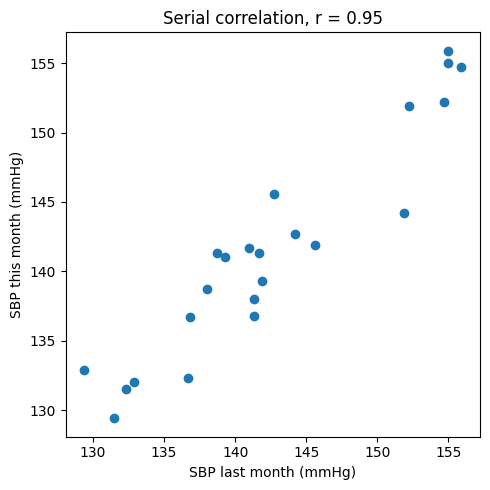

In [8]:
plt.figure(figsize=(5, 5))
plt.scatter(ts["sbp_lag1"], ts["sbp"])
plt.xlabel("SBP last month (mmHg)")
plt.ylabel("SBP this month (mmHg)")
plt.title(f"Serial correlation, r = {r1:.2f}")
plt.tight_layout()
plt.show()

## Recap

| Data type | Structure | Independence | This notebook |
|---|---|---|---|
| Cross-sectional | many units, one period | assumed independent | 200 patients, one visit |
| **Time series** | one unit, many periods | **serially correlated** | ✅ 1 patient, 24 months |
| Pooled cross sections | independent samples in several periods | independent | new samples in 2024 and 2025 |
| Panel / longitudinal | same units over time | both dimensions | 200 patients × 24 months |